<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/chapter1_sinusoid_world/Explaining_the_DFT_a_music_perspective_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform
## George Tzanetakis - Department of Computer Science, University of Victoria

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.



# PART 1 Synthesizing sounds and melodies using sinusoids

## Sinusoids as mathematical abstractions for understanding sound

A sinusoid is a type of continuous curve with a specific repeating shape. It is a mathematical abstraction that can help us reason about a variety of real-world phenomena. It is an idealization similarly to how a circle or an infinite line are mathematical abstractions that can help us solve concrete problems in physical gemotry. Real-word signals don't last forever and in many cases are discrete in nature. For example, audio signals are changes in air pressure created by disturbing a large but finite number of air molecules and have a finite duration. It is important to keep in mind that sinusoidal signals are conceptual abstractions as this will inform us about both the advantages of using them as well as their limitations when modeling actual audio signals.

The equation for a continuous sinusoid is:
$$
f(t) = \alpha sin(\omega t + \phi)\;\;\;\; \text{with} \;\;\;   -\infty < t < +\infty
$$

A **sinusoid** is a function of a continuous variable $t$ representing time. Each sinusoid is uniquely characterized by three numbers: the amplitude $\alpha$, the frequency $\omega$, and the phase $\phi$. The notation and the units of measurement of each number can change but it is important to keep in mind for the rest of the exposition that each sinusoidal signal is characterized uniquely by these three real numbers numbers.

## Sampling and Quantization

Our goal is to process audio signals using computers. Computers need to operate on discrete numerical values that are represented by a finite number of bits. Sampling refers to the process of taking measurements of the signal under consideration at discrete regular time intervals (for example we can sample/measure the temperature of a lake every 1 hour). For each time instance we have a corrsesponding measurement of the value of the signal. This measurement needs to be represented using a set of discrete values represented using a finite number of bits. As an example, a compact disc stores digital audio samples at a sampling rate of 44100 samples/second and each sample is represented as an 16-bit integer. For the remaining of the notebook, we will be working with audio signals with values represented as floating point numbers between -1.0 and 1.0 as this make audio processing easier. We will also be showing plots that look as if the underlying signal is continuous so it is useful to keep in mind that the actual representation is discrete arrays of audio samples as shown in the plot of the sinusoids with stems on each value shown below.



## Playing and plotting a sinusoid signal

So after sampling and quantization we can represent sinusoids (and as we will see any other sound) as very large array of floating point numbers between -1.0 and 1.0. We can generate some samples (corresponding to a specific duration) of a sinusoid of a particular frequency and then see view the corresponding plot. In the example below I use a very low sampling rate (compared to audio sampling rates) so that we can show with plots the difference between the continuous curve plotting that we will be using and contrast it with the more accurate stem plot that shows each individual audio sample.

In [16]:

import numpy as np
import IPython.display as ipd
import librosa
%matplotlib inline
import logging
import matplotlib.pyplot as plt
# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()

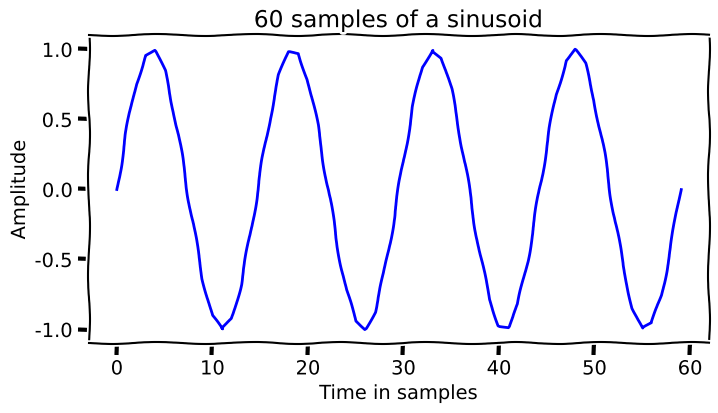

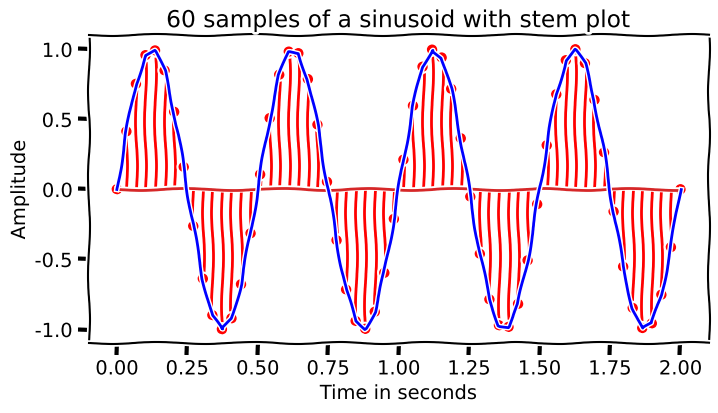

In [17]:

srate = 30         # sampling rate 30 samples a second
duration = 2       # duration in seconds
freq = 2           # frequency in Hz

t = np.linspace(0,duration,srate*duration)     # time instances of samples
data =  np.sin(2*np.pi*freq*t);                # audio samples

fig = plt.figure(figsize=(8,4))
plt.xlabel("Time in samples")
plt.ylabel("Amplitude")
plt.title("60 samples of a sinusoid")
plt.plot(data[0:120], lw=2, color='blue')
fig = plt.figure(figsize=(8,4))
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.title("60 samples of a sinusoid with stem plot")
plt.stem(t[0:120],data[0:120], 'r', )
plt.plot(t[0:120], data[0:120], color='blue')
plt.show()




Now let's create a sinusoidal sound of a specific duration with more realistic parameters for sampling rate, frequency, and duration that we can actuallty hear.

In [18]:
srate = 22050      # sampling rate
duration = 2       # duration in seconds
freq = 440         # frequency in herz

t = np.linspace(0,duration,srate*duration)     # time instances of samples
data =  np.sin(2*np.pi*freq*t);                # audio samples

# play the corresponding audio (normalize=False stops the playback utility from
# normalizing the audio i.e making
# the largest sample equal to 1.0
my_audio_object = ipd.Audio(data,rate=srate, normalize=False)
with open("sine.wav", "wb") as f:
    f.write(my_audio_object.data)
ipd.Audio(data, rate=srate, normalize=False)

In [19]:
# Let's use the code above to create a function that will return an array of
# time points and the corresponding audio samples

def generate_sinusoid(amp = 1.0, freq = 440.0, phase=0.0, dur = 1.0, srate =srate):
  t = np.linspace(0,dur, int(srate* dur))
  data = amp * np.sin(2*np.pi*freq*t+phase)
  return (t,data)

(t,audio) = generate_sinusoid(amp=1.0, freq=220.0, phase=0.0, dur=2.0)
ipd.Audio(audio, rate=srate, normalize=False)


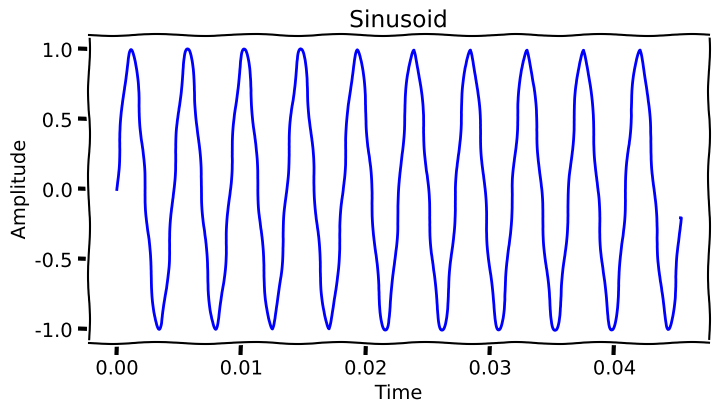

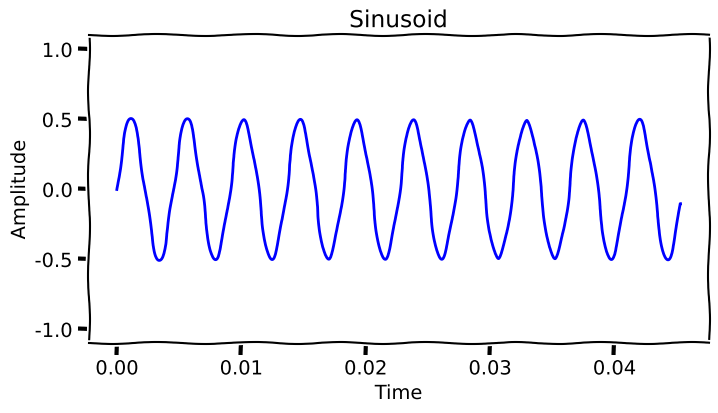

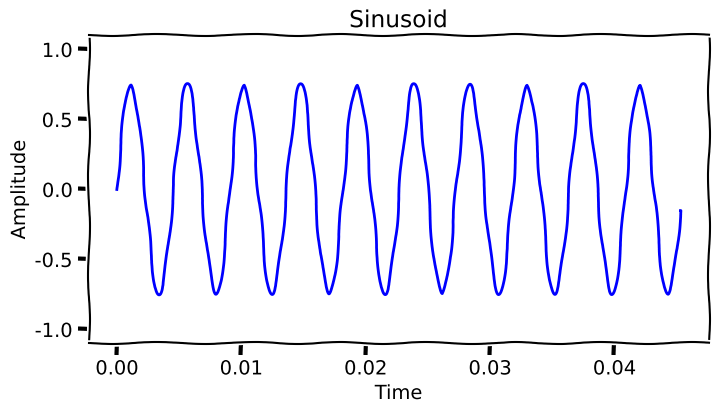

In [20]:
def plot_samples(t, data, start_samples = 0, end_samples = 1000, xlabel="Time", ylabel="Amplitude", title="Sinusoid"):
  fig = plt.figure(figsize=(8,4))
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.ylim(-1.1, 1.1) # set the upper and lower limit of the plot

  plt.plot(t[start_samples:end_samples], data[start_samples:end_samples], lw=2, color='blue')
  plt.show()

# create sinusoids with a different amplitudes but the same frequency
(t,audio2) = generate_sinusoid(amp=0.5, freq=220.0, dur=2.0, phase=0.0)
(t,audio3) = generate_sinusoid(amp = 0.75, freq=220)
plot_samples(t, audio)
plot_samples(t, audio2)
plot_samples(t,audio3)

## Playing a simple melody using sinusoids

Sinusoids are theoretically infinite signals but we can calculate the samples for a finite duration as we have been doing. By appropriately setting up frequencies and amplitudes we can create recognizable melodies i.e sequences of what are called pitches or notes in music theory. For example we can set
the frequencies of the notes called C, D, and E in Western music.
The details of how specific frequencies are mapped top discrete labels called pitches is a complex and fascinating topic and it involves the creation of what are called tuning systems. You can experiment with changing the durations and order of the notes and listen to how it affects how you hear the corresponding melody.

In [21]:
# frequencies of three notes (C, D, E)
c_freq = 523.0
d_freq = 587.0
e_freq = 659.0

# generate sine signals corresponding to each note
(t,c_data) = generate_sinusoid(freq = c_freq, dur = 0.5, amp = 0.5, srate = srate)
(t,d_data) = generate_sinusoid(freq = d_freq, dur = 0.5, amp = 0.5)
(t,e_data) = generate_sinusoid(freq = e_freq, dur = 0.5, amp = 0.5)

# form a simple melody by concateneting the signal arrays for each note
melody = np.hstack([c_data, d_data, e_data, c_data, c_data, d_data, e_data, c_data])

ipd.Audio(melody,rate=srate, normalize=False)



## Side note - Amplitude Envelopes

In the previous melody example you can hear that each note starts and ends abruptly. Musical instruments produce pitches that change in amplitude over time. A typical way to model this in sound synthesis is to use amplitude envelopes that specify how the amplitude of the sound changes over time. Even using a simple sinusoidal oscillator by appropriately setting the frequency and amplitude envelope we can get very different sounds. Amplitude envelopes can have any shape but a classic representation is what is called a ADSR (Attack, Decay, Sustain, Release envelope). Let's check how this works with a sound example.

In [22]:
import numpy as np

def generate_adsr_envelope(dur, attack_pct, decay_pct, sustain_level, release_pct, srate=44100):
    # 1. Validate that the combined percentage stages do not exceed 100% (1.0)
    adr_sum = attack_pct + decay_pct + release_pct
    if adr_sum > 1.0:
        raise ValueError(
            f"The sum of Attack, Decay, and Release percentages ({adr_sum * 100:.1f}%) "
            f"cannot exceed 100%."
        )
    sustain_pct = 1.0 - adr_sum
    total_samples = int(dur * srate)

    # setup number of samples for each stage
    a_samples = int(attack_pct * total_samples)
    d_samples = int(decay_pct * total_samples)
    r_samples = int(release_pct * total_samples)
    s_samples = total_samples - (a_samples + d_samples + r_samples)

    # calculate ramps
    attack_stage = np.linspace(0.0, 1.0, a_samples, endpoint=False)
    decay_stage = np.linspace(1.0, sustain_level, d_samples, endpoint=False)
    sustain_stage = np.full(s_samples, sustain_level)
    release_stage = np.linspace(sustain_level, 0.0, r_samples, endpoint=True)

    envelope = np.concatenate([attack_stage, decay_stage, sustain_stage, release_stage])
    return envelope

ENVELOPE_PRESETS = {
    "bass":    {"attack_pct": 0.00, "decay_pct": 0.30, "sustain_level": 0.0, "release_pct": 0.70},
    "pad": {"attack_pct": 0.25, "decay_pct": 0.15, "sustain_level": 0.7, "release_pct": 0.35},
    "pluck": {"attack_pct": 0.05, "decay_pct": 0.10, "sustain_level": 0.8, "release_pct": 0.10}
}

PITCH_PRESETS = {
    "bass": 32.70,   # Note: C1 (Deep, physical sub-bass)
    "pad": 440.00, # Note: A4 (Clear, warm mid-range)
    "pluck": 1046.50 # Note: C6 (Bright, piercing high-range)
}

(t,bass_data) = generate_sinusoid(freq = PITCH_PRESETS["bass"], dur = 1.5, amp = 0.5, srate = srate)
(t,mid_data)  = generate_sinusoid(freq = PITCH_PRESETS["pad"], dur = 2, amp = 0.5)
(t,high_data)  = generate_sinusoid(freq = PITCH_PRESETS["pluck"], dur = 0.6, amp = 0.5)

audio = np.hstack([bass_data, mid_data, high_data])
ipd.Audio(audio,rate=srate, normalize=False)



In [23]:
bass_envelope = generate_adsr_envelope(dur=1.5, **ENVELOPE_PRESETS["bass"], srate=srate)
mid_envelope = generate_adsr_envelope(dur=2, **ENVELOPE_PRESETS["pad"], srate=srate)
high_envelope = generate_adsr_envelope(dur=0.6, **ENVELOPE_PRESETS["pluck"], srate=srate)

bass_data = bass_data * bass_envelope
mid_data = mid_data * mid_envelope
high_data = high_data * high_envelope

audio = np.hstack([bass_data, mid_data, high_data])
ipd.Audio(audio,rate=srate, normalize=False)


Chip tune music refers to music created using primitive sound chips in the 1980s that only supported basic simple waveforms like sinusoidal oscillators and amplitude envelopes. We can create a simple chip tune like piece.


In [24]:
import numpy as np
import IPython.display as ipd


sample_rate = 44100
bpm = 120
beat_duration = 60.0 / bpm             # 0.5 seconds per beat
total_beats = 8
total_duration = total_beats * beat_duration  # 4.0 seconds total tracking
total_samples = int(total_duration * sample_rate)

PITCH_PRESETS = {
    "sub_bass": 65.40,     # C1
    "ambient_pad": 392.0, # C4 (Lowered slightly for a thicker pad chord)
    "retro_pluck": 1046.50 # C6
}

ENVELOPE_PRESETS = {
    "sub_bass":    {"attack_pct": 0.00, "decay_pct": 0.30, "sustain_level": 0.0, "release_pct": 0.70},
    "ambient_pad": {"attack_pct": 0.25, "decay_pct": 0.15, "sustain_level": 0.7, "release_pct": 0.35},
    "retro_pluck": {"attack_pct": 0.05, "decay_pct": 0.10, "sustain_level": 0.8, "release_pct": 0.10}
}


def add_note(amp, timeline, start_beat, duration_beats, frequency, envelope_type):
    # Calculate timeline index positions
    start_sample = int(start_beat * beat_duration * sample_rate)
    note_duration_sec = duration_beats * beat_duration
    note_samples = int(note_duration_sec * sample_rate)

    # Generate raw tone and apply its target ADSR profile
    t = np.linspace(0, note_duration_sec, note_samples, endpoint=False)
    sine_wave = np.sin(2 * np.pi * frequency * t)
    envelope = generate_adsr_envelope(
        dur=note_duration_sec,
        srate=sample_rate,
        **ENVELOPE_PRESETS[envelope_type]
    )
    timeline[start_sample : start_sample + note_samples] += amp * (sine_wave * envelope)

song_timeline = np.zeros(total_samples)

# Layer 1: Ambient Pad (Swells once over the full 8 beats)
add_note(0.1, song_timeline, start_beat=0, duration_beats=8, frequency=PITCH_PRESETS["ambient_pad"], envelope_type="ambient_pad")

# Layer 2: The Sub-Bass Kick (Hits on every beat)
for beat in [0, 1, 2, 3, 4, 5, 6, 7]:
    add_note(1.0, song_timeline, start_beat=beat, duration_beats=1, frequency=PITCH_PRESETS["sub_bass"], envelope_type="sub_bass")


def midi_to_freq(midi_note):
    """Converts a standard MIDI note integer into a precise frequency in Hz."""
    if midi_note == 0:  # Use 0 to denote a rest (silence)
        return 0.0
    return 440.0 * (2.0 ** ((midi_note - 69) / 12.0))

melody_score = [
    (79, 0, 2),    # G5
    (74, 2, 1),    # D5
    (75, 3, 1),    # D#5
    (77, 4, 2),    # F5
    (75, 6, 1),    # D#5
    (74, 7, 1),    # D5
    (72, 8, 2),    # C5
    (72, 10, 1),   # C5
    (75, 11, 1),   # D#5
    (79, 12, 2),   # G5
    (77, 14, 1),   # F5
    (75, 15, 1)    # D#5
]


melody = [79, 79, 74, 75, 77, 75, 74, 72, 72, 75, 79, 77, 75]
for beat in range(len(melody)):
  freq_mod = midi_to_freq(melody[beat])
  add_note(0.2, song_timeline, start_beat=beat/4, duration_beats=0.3, frequency=freq_mod, envelope_type="retro_pluck")


song_timeline = (song_timeline / np.max(np.abs(song_timeline))) * 0.85

# Output the interactive song player widget
ipd.Audio(song_timeline, rate=srate)

## Adding sinusoidal signals

Sinusoidal signals can be added together. The resulting signal is also infinite and periodic but will have a different shape. Let's listen and plot some linear combinations of sinusoids. For certain combinations of frequencies our ear hears a single complex sound rather than the individual sinusoids that are played together. This is called additive synthesis. As we will later see, any complex sound can be modelled as an addition of multiple sinusoids with appropriate values for the frequencies, durations, amplitudes, and phases. In the example below you can hear how the combination of three sinusoids sounds. These sinusoids are **harmonically related** which means that their corresponding frequencies are all multiples of the same frequency which is called the **fundamental**. We can also use an envelope to make this more complex sound more similar to an actual instrument sound (sounds like an organ).



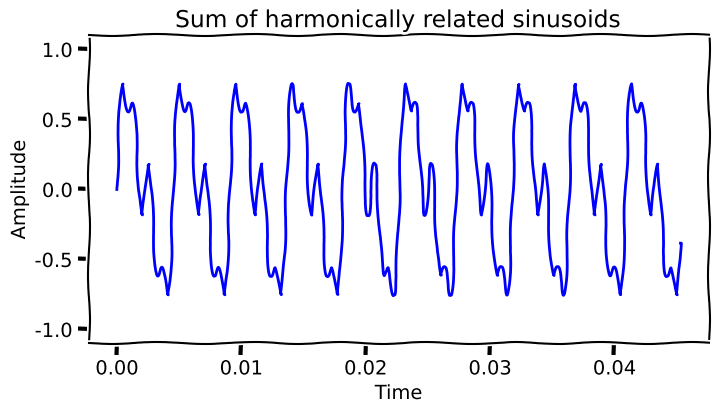

In [25]:
(t,s1) = generate_sinusoid(amp = 0.6, freq = 220.0, dur = 1.0, phase = 0)
(t,s2) = generate_sinusoid(amp = 0.3, freq = 440.0, dur = 1.0, phase = 0)
(t,s3) = generate_sinusoid(amp = 0.2, freq = 880.0, dur = 1.0, phase = 0)

s = np.concatenate([s1+s2+s3, s1+s2, s1], axis=0)
plot_samples(t,s, title="Sum of harmonically related sinusoids")
my_audio_object = ipd.Audio(s, rate=srate, normalize=False)

with open("additive_organ.wav", "wb") as f:
    f.write(my_audio_object.data)



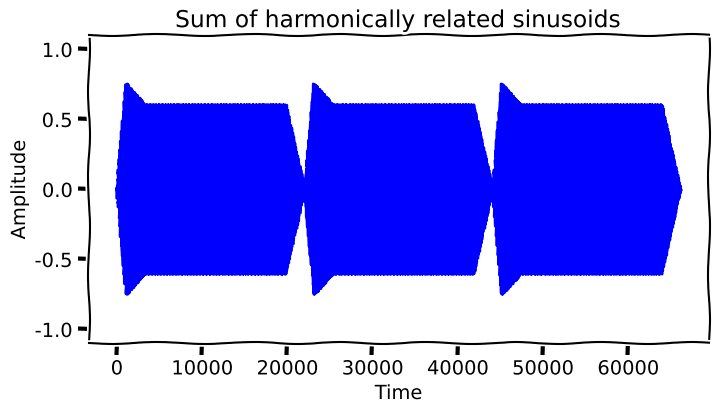

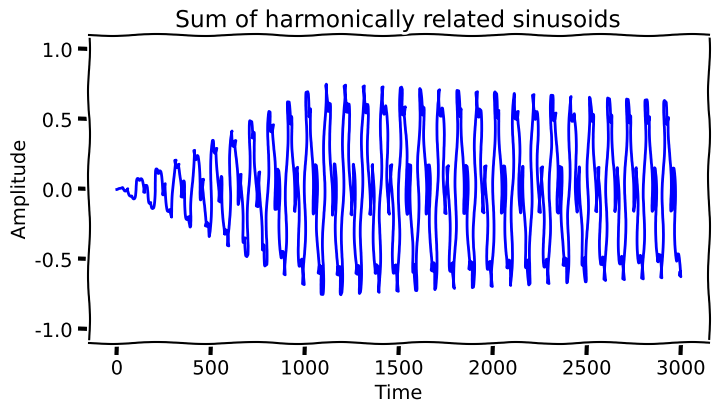

In [26]:
env = generate_adsr_envelope(dur=1.0, **ENVELOPE_PRESETS["retro_pluck"], srate=srate)
n1 = (s1+s2+s3) * env
n = np.concatenate([n1, n1, n1], axis=0)
plot_samples(np.arange(len(n)),n, end_samples = 3*srate, title="Sum of harmonically related sinusoids")
plot_samples(np.arange(len(n)),n, end_samples = 3000, title="Sum of harmonically related sinusoids")

ipd.Audio(n, rate=srate, normalize=False)

When the sinusoids being added are not harmonically related - one can hear more clearly the individual sinusoids in the combined sound and the combined sound is more complex and harsher than when they are harmonically related. You can experiment with the amplitudes and frequencies to see how the resulting sound is affected.

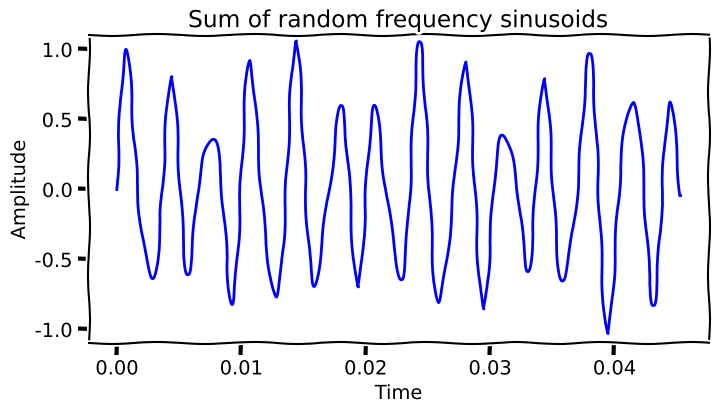

In [27]:
(t,s1) = generate_sinusoid(amp = 0.2, freq = 220.0, dur = 2.0, phase = 0)
(t,s2) = generate_sinusoid(amp = 0.7, freq = 297.0, dur = 2.0, phase = 0)
(t,s3) = generate_sinusoid(amp = 0.2, freq = 503.0, dur = 2.0, phase = 0)

s = np.concatenate([s1+s2+s3, s1+s2, s1], axis=0)
plot_samples(t,s, title="Sum of random frequency sinusoids")
ipd.Audio(s, rate=srate)

We can synthesize a rich bell sound using additive synthesis
with separate envelope for each sinusoidal component of the sound (called a partial).

In [28]:

def generate_rich_bell(root_frequency, duration_sec=5.0, srate=44100):
    """
    Synthesizes a rich bell sound using inharmonic additive synthesis
    and unique per-partial decay envelopes.
    """
    total_samples = int(duration_sec * srate)
    bell_signal = np.zeros(total_samples)
    t = np.linspace(0, duration_sec, total_samples, endpoint=False)

    # Define the 6 partials: (Frequency Multiplier, Relative Amplitude/Volume)
    # Note the inharmonic 1.19 (minor 3rd) and 4.1 (high strike ping)
    partials_config = [
        {"mult": 0.5,  "amp": 0.5,  "env": {"attack_pct": 0.01, "decay_pct": 0.50, "sustain_level": 0.0, "release_pct": 0.49}}, # Hum
        {"mult": 1.0,  "amp": 1.0,  "env": {"attack_pct": 0.00, "decay_pct": 0.40, "sustain_level": 0.0, "release_pct": 0.60}}, # Fundamental
        {"mult": 1.19, "amp": 0.6,  "env": {"attack_pct": 0.00, "decay_pct": 0.30, "sustain_level": 0.0, "release_pct": 0.70}}, # Minor 3rd
        {"mult": 1.5,  "amp": 0.4,  "env": {"attack_pct": 0.00, "decay_pct": 0.25, "sustain_level": 0.0, "release_pct": 0.75}}, # Fifth
        {"mult": 2.0,  "amp": 0.5,  "env": {"attack_pct": 0.00, "decay_pct": 0.20, "sustain_level": 0.0, "release_pct": 0.80}}, # Octave
        {"mult": 4.1,  "amp": 0.7,  "env": {"attack_pct": 0.00, "decay_pct": 0.05, "sustain_level": 0.0, "release_pct": 0.95}}  # High Strike
    ]

    # Render and sum each partial layer
    for p in partials_config:
        freq = root_frequency * p["mult"]
        raw_sine = np.sin(2 * np.pi * freq * t)

        # Generate the specific envelope for this frequency component
        envelope = generate_adsr_envelope(
            dur=duration_sec,
            srate=srate,
            **p["env"]
        )

        # Add the weighted partial to the combined signal
        bell_signal += raw_sine * envelope * p["amp"]

    # Standardize amplitude to avoid digital clipping distortion
    bell_signal = (bell_signal / np.max(np.abs(bell_signal))) * 0.85
    return bell_signal

# --- Execution ---
sample_rate = 44100
# Generate a resonant A4 Bell spanning a 6.0 second decay trail
rendered_bell1 = generate_rich_bell(root_frequency=329.00, duration_sec=3.0, srate=srate)
rendered_bell2 = generate_rich_bell(root_frequency=261.00, duration_sec=2.0, srate=srate)
rendered_bell3 = generate_rich_bell(root_frequency=196.00, duration_sec=2.0, srate=srate)
rendered_bell = np.concatenate([rendered_bell1, rendered_bell2, rendered_bell3, rendered_bell3])
ipd.Audio(rendered_bell, rate=sample_rate)


## Sinusoids as building blocks

So as a first observation we notice that we can get more complex sounds by adding sinusoids. A second observation is that when the corresponding frequencies are integer multiples of each other the resulting sound is less dissonant and "fuses" into a single coherent sound. The third observation is that informally we have seen that we can create simple melodies by appropriately playing sinusoids at particular frequencies and durations and that we can create more complex sounds by adding together sinusoids of different frequencies. The resulting complex sounds can be quite fascinating as can be seen in the famous THX Logo:

[THX Logo in Python](https://musicinformationretrieval.com/content/11_fun/thx_logo_theme.html
)

The THX logo is created by appropriate changing frequencies and amplitudes of a large number of sinusoids over time with appropriately defined envelopes. Armed by what you have learned in this part I encourage you to go over the Python code in the above link and try to understand how it all works.




## The analysis problem

Given these observations for analysis of music signals we would like to be able to take a melody consisting of sinusoids or a complex sound that results from the addition of sinusoids and figure out what are the corresponding frequencies, amplitudes, and phases of the sinusoidal signals that comprise it. If we can figure out a way to do this it will give us a lot of insights about music audio signals and music information retrieval. For example if we were given a sound (always represented as an array of discrete audio samples) consisting of several harmonically related unknown frequencies can we determine what these frequencies are ? If we are given a chip tune as an array of audio samples can we determine what frequencies and amplitudes are present and how they change over time ? This **analysis** problem can be considered the **inverse** problem of **additive audio synthesis**. In Part 2 of this series we will look into how we can solve the analysis problem. This will leads us in understanding the Discrete Fourier Transform a fundamental algorithm in audio processing and music information retrieval.




This notebook can be read as Medium story at:
https://medium.com/@georgetzanetakis/a-music-and-sound-exposition-of-the-discrete-fourier-transform-part-1-79b641ed1078?sharedUserId=georgetzanetakis


